In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.arima.model import ARIMA

## Hàm hỗ trợ

In [2]:
# Hàm lọc dữ liệu time
def clean_text(text):
    return text.split(".")[0]

In [3]:
# Hàm kiểm tra chuỗi có phải dừng không ?
def is_stationary(time_series, table_name):
    time_series = list(time_series)
    adf = adfuller(time_series)
    kp = kpss(time_series, regression='c', nlags="auto")
    check_adf = False
    check_kp = False

    # print('P-value của ADF Statistic:', adf[1])
    if adf[1] < 0.05:
        print(f"ADF: {table_name} là Chuỗi dừng (bác bỏ H0)")
        check_adf = True
    else:
        print(f"ADF {table_name} là Chuỗi không dừng (không bác bỏ H0)")

    # print('p-value của KPSS Statistic:', kp[1])
    if kp[1] > 0.05:
        print(f"KPSS: {table_name} là Chuỗi dừng (bác bỏ H0)")
        check_kp = True
    else:
        print(f"KPSS {table_name} là Chuỗi không dừng (không bác bỏ H0)")

    if check_adf and check_kp:
        return True
    else:
        return False
        

In [4]:
# Hàm mô tả thông tin về chuỗi dừng và chuỗi không dừng
def infor_time_series(time_series_stop, time_series_no_stop):
    print(f"Số chuỗi dừng {len(time_series_stop)}")
    print(f"Số chuỗi không dừng {len(time_series_no_stop)}")
    print(f"Thuộc tính có chuỗi dừng: {time_series_stop.keys()}")
    print(f"Thuộc tính có chuỗi không dừng: {time_series_no_stop.keys()}")

In [5]:
# Hàm chia dữ liệu chuỗi thời gian theo tỉ lệ
def splitting_time_series(time_series, train_size=0.8):
    lst_time_series = list(time_series)
    length = len(time_series)
    train_idx = int(length * train_size)
    return lst_time_series[:train_idx], lst_time_series[train_idx:-10]

## Tiền xử lý dữ liệu

In [6]:
df = pd.read_csv("../data/clean_2days.csv")
df.head()

,time_influx,pm_1_0,pm_2_5,pm_10,temperature,humidity,heat_index,location
0,2025-09-18 06:50:18.856987170+00:00,9.0,19.0,19.0,38.11,79.4,30.2,Location 01
1,2025-09-18 06:50:51.045145887+00:00,8.0,18.0,18.0,38.11,79.4,30.2,Location 01
2,2025-09-18 06:51:23.227159414+00:00,8.0,20.0,19.0,38.11,79.4,30.2,Location 01
3,2025-09-18 06:51:55.511849458+00:00,12.0,22.0,19.0,38.14,79.5,30.2,Location 01
4,2025-09-18 06:52:27.733548894+00:00,10.0,20.0,19.0,38.14,79.5,30.2,Location 01


In [7]:
df = df.iloc[:,:-1]
df.head()

,time_influx,pm_1_0,pm_2_5,pm_10,temperature,humidity,heat_index
0,2025-09-18 06:50:18.856987170+00:00,9.0,19.0,19.0,38.11,79.4,30.2
1,2025-09-18 06:50:51.045145887+00:00,8.0,18.0,18.0,38.11,79.4,30.2
2,2025-09-18 06:51:23.227159414+00:00,8.0,20.0,19.0,38.11,79.4,30.2
3,2025-09-18 06:51:55.511849458+00:00,12.0,22.0,19.0,38.14,79.5,30.2
4,2025-09-18 06:52:27.733548894+00:00,10.0,20.0,19.0,38.14,79.5,30.2


### Đếm số giá trị mỗi thuộc tính

In [8]:
attributes = list(df.columns)[1:]
for attribute in attributes:
    print(f"{attribute}: {df[attribute].count()} giá trị")

pm_1_0: 5356 giá trị
pm_2_5: 5356 giá trị
pm_10: 5356 giá trị
temperature: 115 giá trị
humidity: 115 giá trị
heat_index: 115 giá trị


### Kiểm tra tính dừng mỗi table

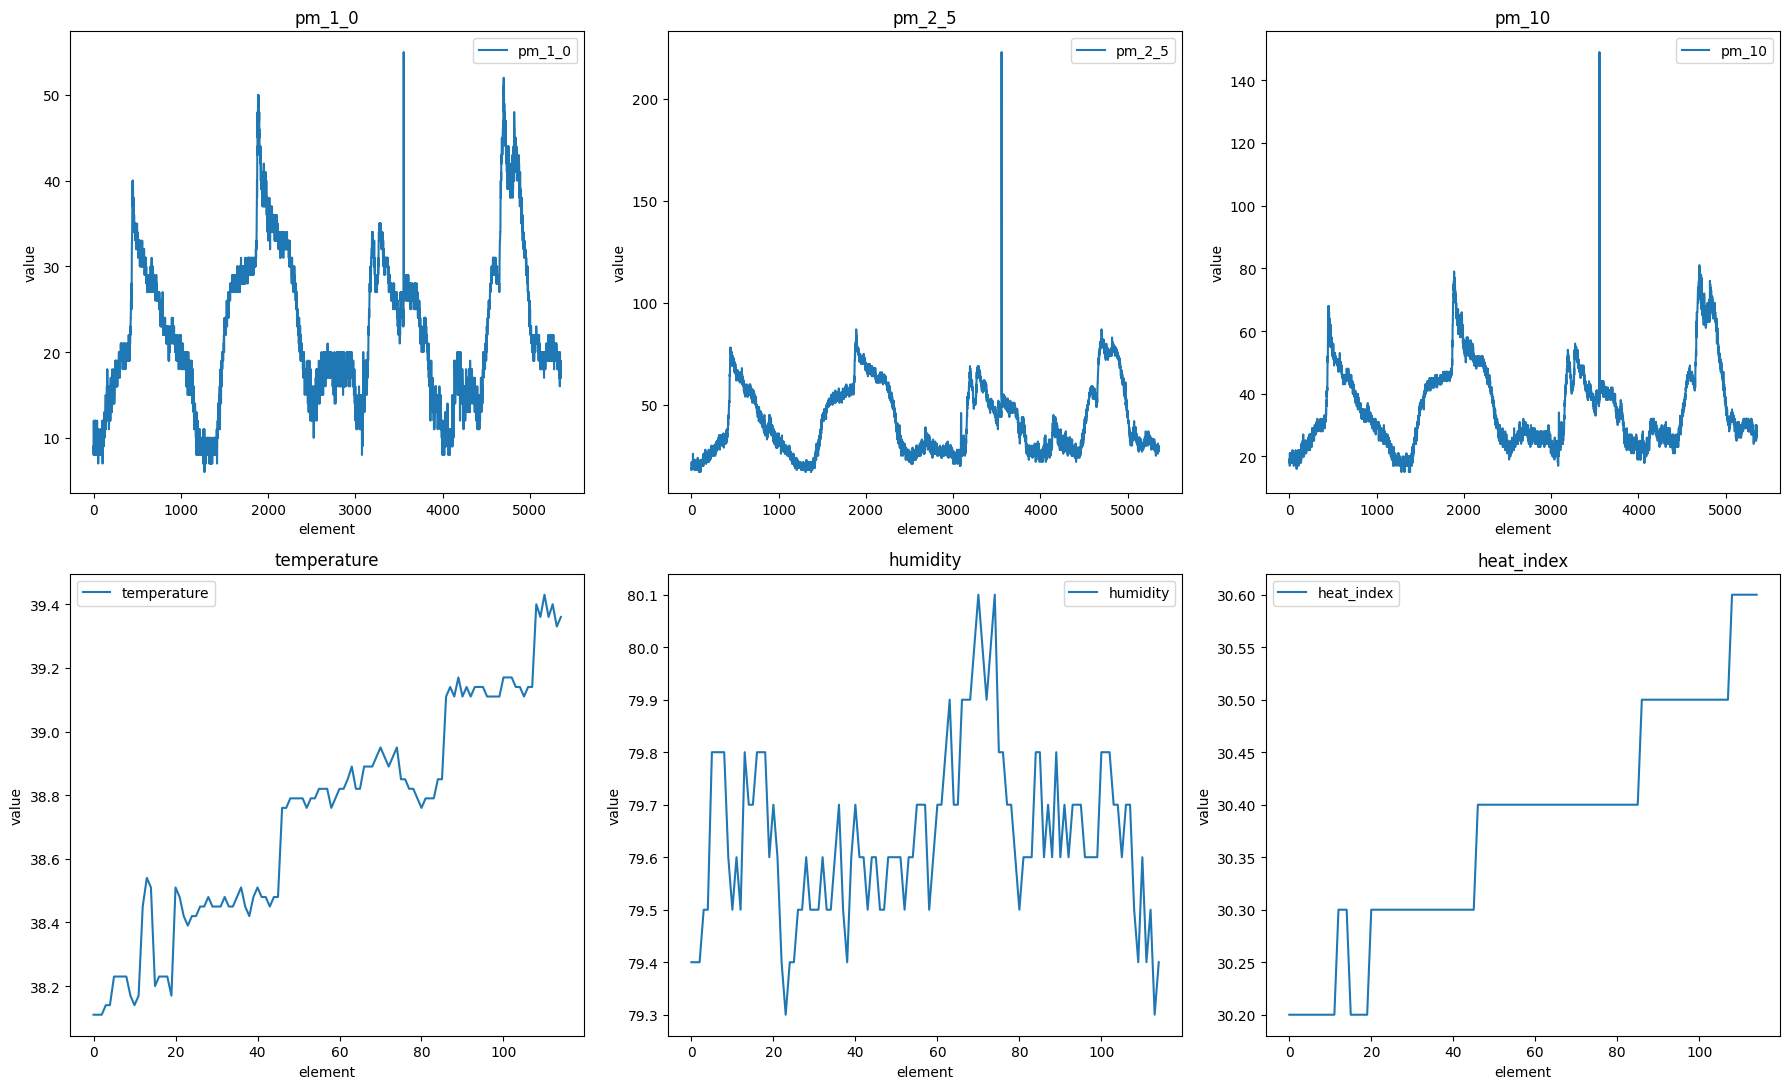

In [9]:
fig, axes = plt.subplots(2,3, figsize=(18,11))
axes = axes.flatten()

for i in range(len(attributes)):
    df.plot(ax=axes[i] ,y=attributes[i])
    axes[i].set_title(attributes[i])
    axes[i].set_xlabel("element")
    axes[i].set_ylabel("value")

plt.tight_layout()
plt.show()

In [10]:
time_series_stop = {}
time_series_no_stop = {}

for attribute in attributes:
    time_series = df[attribute].dropna().reset_index(drop=True)
    print(f"{attribute}: {list(time_series)}")

    if is_stationary(time_series, attribute):
        print(f"- {attribute} LÀ CHUỖI DỪNG !")
        time_series_stop[attribute] = time_series
    else:
        print(f"- {attribute} LÀ CHUỖI KHÔNG DỪNG !")
        time_series_no_stop[attribute] = time_series
    

pm_1_0: [9.0, 8.0, 8.0, 12.0, 10.0, 8.0, 9.0, 10.0, 9.0, 9.0, 8.0, 10.0, 9.0, 9.0, 11.0, 10.0, 9.0, 11.0, 12.0, 8.0, 10.0, 8.0, 12.0, 11.0, 11.0, 9.0, 9.0, 9.0, 11.0, 10.0, 10.0, 11.0, 10.0, 11.0, 11.0, 8.0, 10.0, 9.0, 9.0, 9.0, 10.0, 12.0, 10.0, 11.0, 9.0, 10.0, 9.0, 9.0, 10.0, 8.0, 9.0, 11.0, 9.0, 10.0, 7.0, 9.0, 11.0, 10.0, 9.0, 10.0, 10.0, 9.0, 9.0, 10.0, 8.0, 9.0, 10.0, 9.0, 10.0, 9.0, 10.0, 9.0, 8.0, 9.0, 10.0, 10.0, 11.0, 9.0, 9.0, 10.0, 10.0, 10.0, 10.0, 8.0, 8.0, 10.0, 9.0, 9.0, 8.0, 10.0, 9.0, 10.0, 11.0, 9.0, 11.0, 9.0, 11.0, 8.0, 9.0, 9.0, 8.0, 9.0, 12.0, 10.0, 7.0, 9.0, 10.0, 10.0, 12.0, 10.0, 9.0, 10.0, 12.0, 10.0, 11.0, 11.0, 10.0, 9.0, 10.0, 10.0, 10.0, 12.0, 10.0, 13.0, 11.0, 11.0, 11.0, 10.0, 11.0, 11.0, 11.0, 11.0, 12.0, 11.0, 11.0, 12.0, 12.0, 11.0, 12.0, 12.0, 15.0, 11.0, 13.0, 15.0, 14.0, 14.0, 15.0, 14.0, 13.0, 13.0, 14.0, 15.0, 14.0, 16.0, 14.0, 13.0, 16.0, 16.0, 18.0, 16.0, 15.0, 13.0, 12.0, 13.0, 13.0, 16.0, 14.0, 14.0, 13.0, 13.0, 14.0, 13.0, 13.0, 14.0, 12.0

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_5512\891656084.py:5: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kp = kpss(time_series, regression='c', nlags="auto")
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_5512\891656084.py:5: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kp = kpss(time_series, regression='c', nlags="auto")
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_5512\891656084.py:5: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kp = kpss(time_series, regression='c', nlags="auto")
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_5512\891656084.py:5: InterpolationWarning: The test statistic is outside of the range of p-

In [11]:
infor_time_series(time_series_stop, time_series_no_stop)

Số chuỗi dừng 1
Số chuỗi không dừng 5
Thuộc tính có chuỗi dừng: dict_keys(['humidity'])
Thuộc tính có chuỗi không dừng: dict_keys(['pm_1_0', 'pm_2_5', 'pm_10', 'temperature', 'heat_index'])


### Biến đổi chuỗi để dừng

In [12]:
time_series_no_stop['pm_1_0']

0        9.0
1        8.0
2        8.0
3       12.0
4       10.0
        ... 
5351    18.0
5352    18.0
5353    19.0
5354    19.0
5355    17.0
Name: pm_1_0, Length: 5356, dtype: float64

In [13]:
# Dict lưu số lần sai phân của từng thuộc tính để trở thành chuỗi dừng
number_diff_and_table = {0: list(time_series_stop.keys())}
number_diff_and_table

{0: ['humidity']}

In [14]:
count = 1
while time_series_no_stop:
    # Áp dụng sai phân
    time_series_after_diff = {k: (v.diff().dropna()) for k, v in time_series_no_stop.items()}
    time_series_no_stop = {}
    number_diff_and_table[count] = []
    for attribute, time_series in time_series_after_diff.items():
        if is_stationary(time_series, attribute):
            print(f"- {attribute} LÀ CHUỖI DỪNG SAU {count} LẦN SAI PHÂN !")
            time_series_stop[attribute] = time_series
            number_diff_and_table[count].append(attribute)
        else:
            time_series_no_stop[attribute] = time_series
    count += 1

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_5512\891656084.py:5: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kp = kpss(time_series, regression='c', nlags="auto")
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_5512\891656084.py:5: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kp = kpss(time_series, regression='c', nlags="auto")


ADF: pm_1_0 là Chuỗi dừng (bác bỏ H0)
KPSS: pm_1_0 là Chuỗi dừng (bác bỏ H0)
- pm_1_0 LÀ CHUỖI DỪNG SAU 1 LẦN SAI PHÂN !
ADF: pm_2_5 là Chuỗi dừng (bác bỏ H0)
KPSS: pm_2_5 là Chuỗi dừng (bác bỏ H0)
- pm_2_5 LÀ CHUỖI DỪNG SAU 1 LẦN SAI PHÂN !
ADF: pm_10 là Chuỗi dừng (bác bỏ H0)
KPSS: pm_10 là Chuỗi dừng (bác bỏ H0)
- pm_10 LÀ CHUỖI DỪNG SAU 1 LẦN SAI PHÂN !
ADF: temperature là Chuỗi dừng (bác bỏ H0)
KPSS: temperature là Chuỗi dừng (bác bỏ H0)
- temperature LÀ CHUỖI DỪNG SAU 1 LẦN SAI PHÂN !
ADF: heat_index là Chuỗi dừng (bác bỏ H0)
KPSS: heat_index là Chuỗi dừng (bác bỏ H0)
- heat_index LÀ CHUỖI DỪNG SAU 1 LẦN SAI PHÂN !


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_5512\891656084.py:5: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kp = kpss(time_series, regression='c', nlags="auto")
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_5512\891656084.py:5: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kp = kpss(time_series, regression='c', nlags="auto")
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_5512\891656084.py:5: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kp = kpss(time_series, regression='c', nlags="auto")


In [15]:
time_series_stop['pm_1_0']

1      -1.0
2       0.0
3       4.0
4      -2.0
5      -2.0
       ... 
5351    0.0
5352    0.0
5353    1.0
5354    0.0
5355   -2.0
Name: pm_1_0, Length: 5355, dtype: float64

In [16]:
infor_time_series(time_series_stop, time_series_no_stop)
number_diff_and_table

Số chuỗi dừng 6
Số chuỗi không dừng 0
Thuộc tính có chuỗi dừng: dict_keys(['humidity', 'pm_1_0', 'pm_2_5', 'pm_10', 'temperature', 'heat_index'])
Thuộc tính có chuỗi không dừng: dict_keys([])


{0: ['humidity'],
 1: ['pm_1_0', 'pm_2_5', 'pm_10', 'temperature', 'heat_index']}

## Xây dựng mô hình ARIMA

### Chia tập train, test cho các table
- Biến data có key là table và value là tập train, test đã chia (10 dữ liệu cuối bị cắt)
- Biến real lưu giữ liệu của 10 giá trị cuối, phục vụ kiểm tra việc dự đoán

In [17]:
data = {}
real = {}
for attribute in attributes:
    data[attribute] = splitting_time_series(time_series_stop[attribute])
    real[attribute] = list(time_series_stop[attribute])[-10:]
data

{'pm_1_0': ([-1.0,
   0.0,
   4.0,
   -2.0,
   -2.0,
   1.0,
   1.0,
   -1.0,
   0.0,
   -1.0,
   2.0,
   -1.0,
   0.0,
   2.0,
   -1.0,
   -1.0,
   2.0,
   1.0,
   -4.0,
   2.0,
   -2.0,
   4.0,
   -1.0,
   0.0,
   -2.0,
   0.0,
   0.0,
   2.0,
   -1.0,
   0.0,
   1.0,
   -1.0,
   1.0,
   0.0,
   -3.0,
   2.0,
   -1.0,
   0.0,
   0.0,
   1.0,
   2.0,
   -2.0,
   1.0,
   -2.0,
   1.0,
   -1.0,
   0.0,
   1.0,
   -2.0,
   1.0,
   2.0,
   -2.0,
   1.0,
   -3.0,
   2.0,
   2.0,
   -1.0,
   -1.0,
   1.0,
   0.0,
   -1.0,
   0.0,
   1.0,
   -2.0,
   1.0,
   1.0,
   -1.0,
   1.0,
   -1.0,
   1.0,
   -1.0,
   -1.0,
   1.0,
   1.0,
   0.0,
   1.0,
   -2.0,
   0.0,
   1.0,
   0.0,
   0.0,
   0.0,
   -2.0,
   0.0,
   2.0,
   -1.0,
   0.0,
   -1.0,
   2.0,
   -1.0,
   1.0,
   1.0,
   -2.0,
   2.0,
   -2.0,
   2.0,
   -3.0,
   1.0,
   0.0,
   -1.0,
   1.0,
   3.0,
   -2.0,
   -3.0,
   2.0,
   1.0,
   0.0,
   2.0,
   -2.0,
   -1.0,
   1.0,
   2.0,
   -2.0,
   1.0,
   0.0,
   -1.0,
   -1.0,
   1.0,


In [18]:
real

{'pm_1_0': [-2.0, 1.0, -2.0, 2.0, -1.0, 0.0, 0.0, 1.0, 0.0, -2.0],
 'pm_2_5': [-2.0, -2.0, 0.0, 1.0, 0.0, -1.0, 0.0, 3.0, -1.0, 0.0],
 'pm_10': [-3.0, -1.0, 0.0, -1.0, 1.0, 0.0, 0.0, 4.0, -4.0, 1.0],
 'temperature': [-0.030000000000001137,
  0.030000000000001137,
  0.0,
  0.259999999999998,
  -0.03999999999999915,
  0.07000000000000028,
  -0.07000000000000028,
  0.03999999999999915,
  -0.07000000000000028,
  0.030000000000001137],
 'humidity': [79.6, 79.7, 79.7, 79.5, 79.4, 79.6, 79.4, 79.5, 79.3, 79.4],
 'heat_index': [0.0,
  0.0,
  0.0,
  0.10000000000000142,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0]}

### Khởi tạo và huấn luyện model cho mỗi bảng
- Biến models sẽ lưu các model của từng bảng

In [48]:
models = {}
for number_diff, lst_attributes in number_diff_and_table.items():
    if number_diff_and_table[number_diff]:
        for attribute in lst_attributes:
            model = ARIMA(data[attribute][0], order=(3,number_diff,1))
            models[attribute] = model.fit()
            print(f"Huấn luyện thành công model cho {attribute}")

Huấn luyện thành công model cho humidity
Huấn luyện thành công model cho pm_1_0
Huấn luyện thành công model cho pm_2_5
Huấn luyện thành công model cho pm_10
Huấn luyện thành công model cho temperature
Huấn luyện thành công model cho heat_index


d:\python-workspace\airquality-ml-modeling\.venv\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


### Dự đoán

In [49]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

In [50]:
error = {}

In [51]:
for attribute in attributes:
    error[attribute] = []
    print(f'THÔNG TIN DỰ ĐOÁN CỦA {attribute}')

    predict = models[attribute].forecast(steps=10)
    print(f"- Predict: {predict}")
    print(f"- Real: {real[attribute]}")

    error[attribute].append(mean_squared_error(real[attribute], predict))
    error[attribute].append(r2_score(real[attribute], predict))
    error[attribute].append(mean_absolute_error(real[attribute], predict))

THÔNG TIN DỰ ĐOÁN CỦA pm_1_0
- Predict: [ 0.61498033 -0.36144719  0.17615514 -0.08619736  0.05721303 -0.03161778
  0.01645251 -0.00635472  0.0064181  -0.00170068]
- Real: [-2.0, 1.0, -2.0, 2.0, -1.0, 0.0, 0.0, 1.0, 0.0, -2.0]
THÔNG TIN DỰ ĐOÁN CỦA pm_2_5
- Predict: [-2.74653420e+00  9.17950797e-04  4.48566282e-01  3.32132822e-01
 -3.63560140e-01 -7.10840671e-03  8.39249572e-02  3.89204037e-02
 -4.68733255e-02  1.50975238e-03]
- Real: [-2.0, -2.0, 0.0, 1.0, 0.0, -1.0, 0.0, 3.0, -1.0, 0.0]
THÔNG TIN DỰ ĐOÁN CỦA pm_10
- Predict: [-1.39075298 -0.26981254 -0.07875646  0.40478679 -0.15028968 -0.04081804
  0.00715156  0.04279912 -0.01533645 -0.0036316 ]
- Real: [-3.0, -1.0, 0.0, -1.0, 1.0, 0.0, 0.0, 4.0, -4.0, 1.0]
THÔNG TIN DỰ ĐOÁN CỦA temperature
- Predict: [0.00811187 0.02478952 0.00708726 0.0108054  0.00904266 0.0125131
 0.01173608 0.0117605  0.01110214 0.01130014]
- Real: [-0.030000000000001137, 0.030000000000001137, 0.0, 0.259999999999998, -0.03999999999999915, 0.07000000000000028, -0.0

In [52]:
error

{'pm_1_0': [2.3904492146025613, -0.3206901738135697, 1.2355135481301576],
 'pm_2_5': [1.6009742443667747, 0.18317640593531903, 0.9219978328535114],
 'pm_10': [3.897162067289917, 0.1162897806598826, 1.396673306806505],
 'temperature': [0.008374326522934437,
  -0.00459771148446686,
  0.06159113357032338],
 'humidity': [0.0380518742128204, -1.2515901901077489, 0.16343716652212806],
 'heat_index': [0.0009494826168982024,
  -0.0549806854424173,
  0.012915941021726746]}

### Chuyển sang dạng bảng

In [53]:
df_error = pd.DataFrame.from_dict(error, orient='index', columns=['MSE', 'R2 Score', 'MAE'])
df_error

,MSE,R2 Score,MAE
pm_1_0,2.390449,-0.320690,1.235514
pm_2_5,1.600974,0.183176,0.921998
pm_10,3.897162,0.116290,1.396673
temperature,0.008374,-0.004598,0.061591
humidity,0.038052,-1.251590,0.163437
heat_index,0.000949,-0.054981,0.012916
